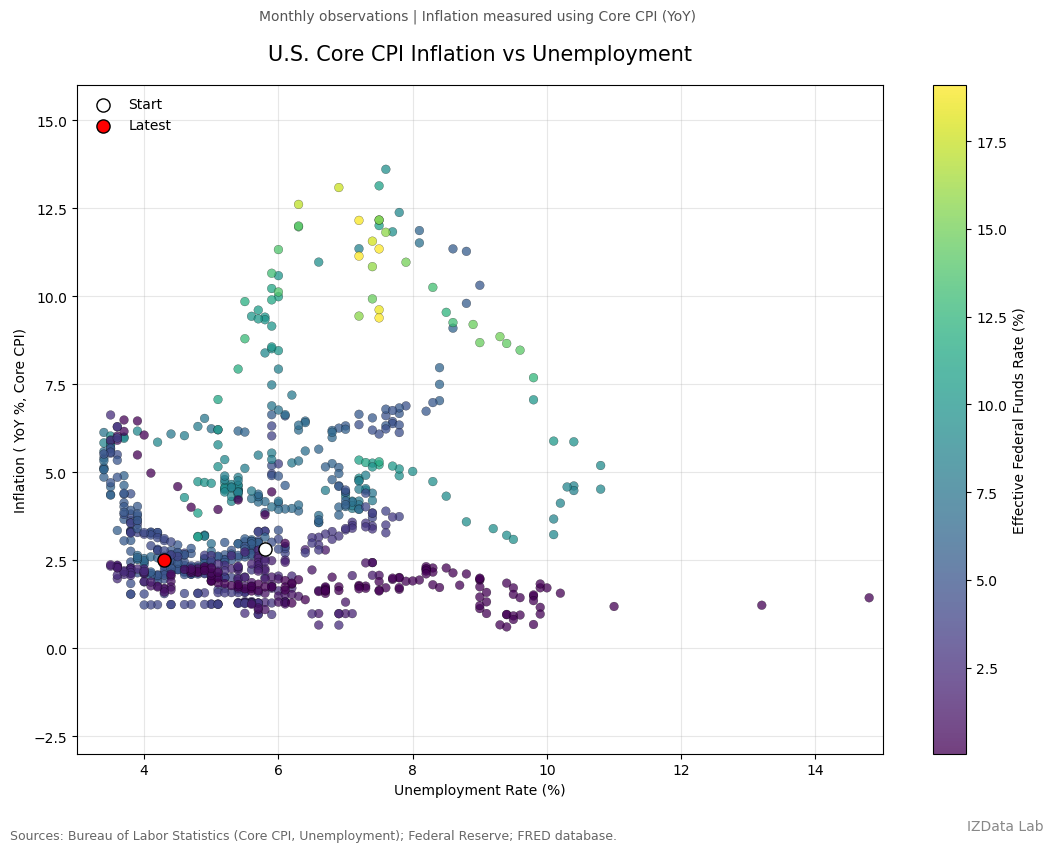

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Load data
# =========================
core_cpi = pd.read_csv("CPILFESL.csv")   # Core CPI (All items less food and energy)
unrate = pd.read_csv("UNRATE.csv")
fed = pd.read_csv("FEDFUNDS.csv")

# =========================
# 2. Convert dates
# =========================
for df_ in [core_cpi, unrate, fed]:
    df_["observation_date"] = pd.to_datetime(df_["observation_date"])

# =========================
# 3. Rename columns
# =========================
core_cpi.rename(columns={"observation_date": "Date", "CPILFESL": "CoreCPI"}, inplace=True)
unrate.rename(columns={"observation_date": "Date", "UNRATE": "Unemployment"}, inplace=True)
fed.rename(columns={"observation_date": "Date", "FEDFUNDS": "FedFunds"}, inplace=True)

# =========================
# 4. Merge datasets
# =========================
df = core_cpi.merge(unrate, on="Date").merge(fed, on="Date")
df = df.sort_values("Date").set_index("Date")

# =========================
# 5. Compute inflation (YoY)
# =========================
df["Inflation"] = df["CoreCPI"].pct_change(12, fill_method=None) * 100
df = df.dropna()

# =========================
# 6. Plot
# =========================
fig, ax = plt.subplots(figsize=(11, 9))

# Scatter points
scatter = ax.scatter(
    df["Unemployment"],
    df["Inflation"],
    c=df["FedFunds"],
    cmap="viridis",
    alpha=0.75,
    s=40,
    edgecolor="k",
    linewidth=0.2,
    zorder=2
)

# Mark start and end points
ax.scatter(
    df["Unemployment"].iloc[0],
    df["Inflation"].iloc[0],
    s=90,
    color="white",
    edgecolor="black",
    linewidth=1.0,
    zorder=3,
    label="Start"
)

ax.scatter(
    df["Unemployment"].iloc[-1],
    df["Inflation"].iloc[-1],
    s=90,
    color="red",
    edgecolor="black",
    linewidth=1.0,
    zorder=3,
    label="Latest"
)


# Labels
ax.set_xlabel("Unemployment Rate (%)")
ax.set_ylabel("Inflation ( YoY %, Core CPI)")

# Title
ax.set_title(
    "U.S. Core CPI Inflation vs Unemployment",
    fontsize=15,
    pad=18
)

# Subtitle
fig.text(
    0.435,
    0.93,
    "Monthly observations | Inflation measured using Core CPI (YoY)",
    ha="center",
    fontsize=10,
    color="#555555"
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Effective Federal Funds Rate (%)")

# Styling
ax.grid(alpha=0.3)
ax.set_xlim(3, 15)
ax.set_ylim(-3, 16)

# Legend
ax.legend(frameon=False, loc="upper left")

# Sources
fig.text(
    0.01,
    0.02,
    "Sources: Bureau of Labor Statistics (Core CPI, Unemployment); Federal Reserve; FRED database.",
    fontsize=9,
    color="#666666",
    ha="left"
)

# Watermark
fig.text(
    0.95,
    0.03,
    "IZData Lab",
    fontsize=10,
    color="#888888",
    ha="right"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.savefig("CoreCPI_vs_Unemployment_with_Path.png", dpi=300, bbox_inches="tight")
plt.show()